# 03 · Análisis exploratorio por versión

Compara las versiones registradas: qué descarta cada filtro, cómo quedan las
métricas de calidad frente a sus umbrales, el balance por especie y qué cambió
entre una versión y la siguiente.

In [13]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from corpus import BASE, METADATA, PROCESADO_DIR, VERSIONES_DIR, leerCsv

VERSIONES = None        # None = todas las registradas
SPLITS = ("train", "test", "validate")

manifiestos = {p.stem: json.loads(p.read_text())
               for p in sorted(VERSIONES_DIR.glob("*.json"))
               if VERSIONES is None or p.stem in VERSIONES}


def auditoriaDe(version):
    """Las versiones nuevas llevan su auditoría; v1 usa la de la raíz."""
    propia = PROCESADO_DIR / version / "auditoria.csv"
    ruta = propia if propia.exists() else BASE / "auditoria.csv"
    return pd.DataFrame(leerCsv(ruta)) if ruta.exists() else None


def archivosDe(manifiesto, split=None):
    return {a for sp in manifiesto["reparto"].values()
            for s in ([split] if split else SPLITS) for a in sp[s]}


print(f"versiones: {list(manifiestos)}")

versiones: ['v1', 'v2']


## 1 · Resumen comparativo

In [14]:
resumen = pd.DataFrame([{
    "version": nombre,
    "clases": m["num_clases"],
    **{s: m["conteos"][s] for s in SPLITS},
    "total": m["conteos"]["total"],
    **{f"umbral_{k}": v for k, v in m["parametros"]["umbrales"].items()},
    "semilla": m["parametros"]["semilla"],
} for nombre, m in manifiestos.items()]).set_index("version")
resumen

,clases,train,test,validate,total,umbral_nitidez,umbral_fracSaturados,umbral_fracNegros,umbral_ladoOriginal,semilla
version,,,,,,,,,,
v1,79,7214,2061,1038,10313,60.0,0.06,0.2,200,42
v2,79,11774,3364,1686,16824,60.0,0.06,0.2,200,42


## 2 · Qué descarta cada filtro

La cascada es excluyente: el primer motivo que aplica gana, así que los
porcentajes suman el corpus completo.

In [15]:
motivos = {}
for nombre in manifiestos:
    aud = auditoriaDe(nombre)
    if aud is None:
        continue
    motivos[nombre] = aud.motivo.value_counts()

descartes = pd.DataFrame(motivos).fillna(0).astype(int)
descartes["% en " + descartes.columns[-1]] = (
    100 * descartes.iloc[:, -1] / descartes.iloc[:, -1].sum()).round(2)
descartes.sort_values(descartes.columns[0], ascending=False)

,v1,v2,% en v2
motivo,,,
aceptada,10318,16829,71.57
sobreexpuesta,1717,2654,11.29
desenfocada,652,1067,4.54
casi_duplicado,590,988,4.20
recorte_pequeno,457,761,3.24
sin_deteccion,409,764,3.25
subexpuesta,213,320,1.36
especie_escasa,129,132,0.56


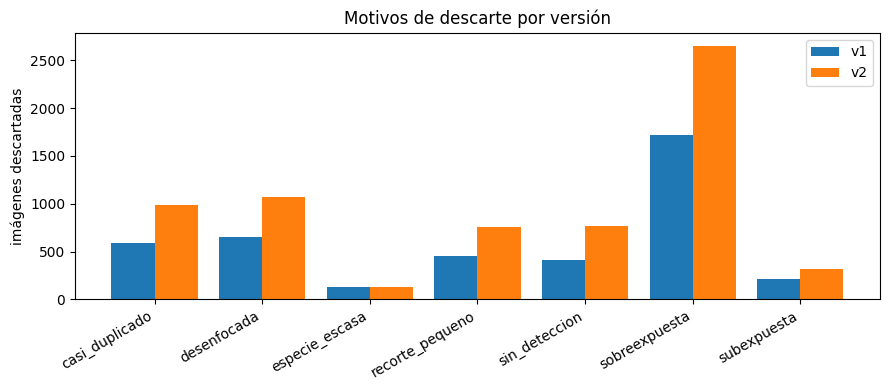

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
orden = [m for m in descartes.index if m != "aceptada"]
x = np.arange(len(orden))
ancho = 0.8 / max(len(motivos), 1)
for i, nombre in enumerate(motivos):
    ax.bar(x + i * ancho, descartes.loc[orden, nombre], ancho, label=nombre)
ax.set_xticks(x + ancho * (len(motivos) - 1) / 2, orden, rotation=30, ha="right")
ax.set(ylabel="imágenes descartadas", title="Motivos de descarte por versión")
ax.legend()
fig.tight_layout()
plt.show()

## 3 · Métricas de calidad frente a sus umbrales

Dónde cae el umbral congelado dentro de la distribución real. Es la vista para
decidir si moverlo, y cuánto costaría hacerlo.

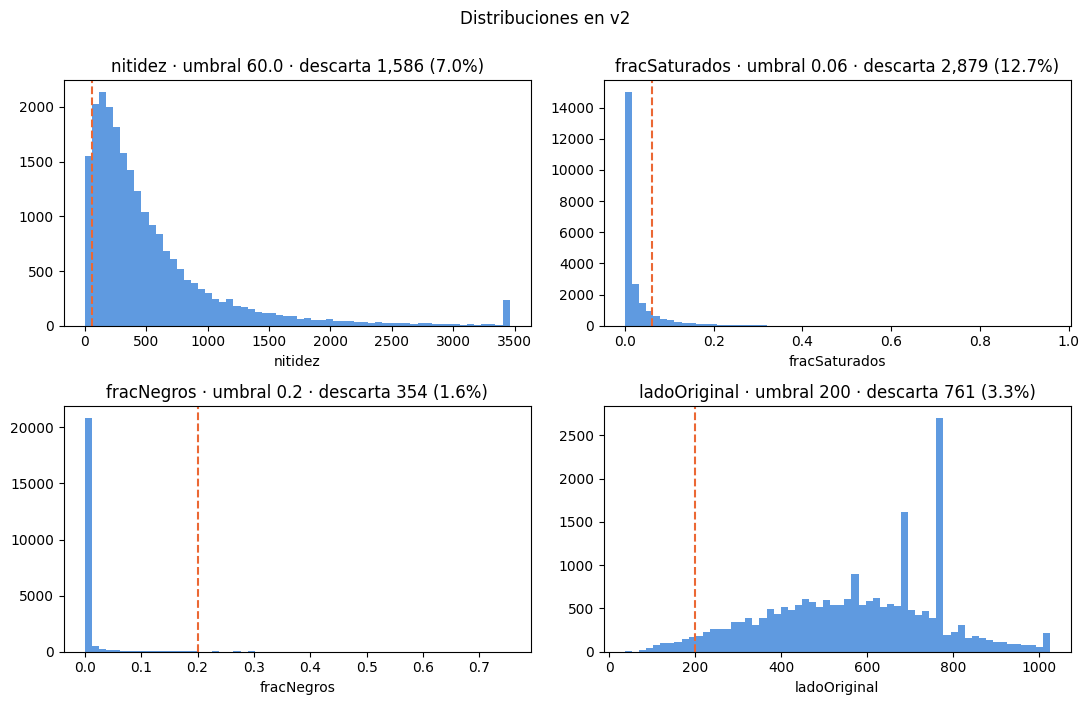

In [17]:
VERSION_CALIDAD = list(manifiestos)[-1]
aud = auditoriaDe(VERSION_CALIDAD)
umbrales = manifiestos[VERSION_CALIDAD]["parametros"]["umbrales"]

numericas = aud[aud.nitidez != ""].copy()
for col in ("nitidez", "fracSaturados", "fracNegros", "ladoOriginal"):
    numericas[col] = numericas[col].astype(float)

fig, ejes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (col, umbral) in zip(ejes.ravel(), umbrales.items()):
    serie = numericas[col]
    recorte = serie.quantile(0.99) if col == "nitidez" else serie.max()
    ax.hist(serie.clip(upper=recorte), bins=60, color="#2a78d6", alpha=0.75)
    ax.axvline(umbral, color="#eb6834", linestyle="--", linewidth=1.5)
    descartadas = (serie < umbral) if col in ("nitidez", "ladoOriginal") else (serie > umbral)
    ax.set(title=f"{col} · umbral {umbral} · descarta {descartadas.sum():,} "
                 f"({descartadas.mean():.1%})", xlabel=col)
fig.suptitle(f"Distribuciones en {VERSION_CALIDAD}", y=1.0)
fig.tight_layout()
plt.show()

### Cuánto ganaría mover cada umbral

Solo cuenta las que ese filtro rechaza en solitario: una foto que además está
desenfocada no se recupera por relajar la exposición.

In [18]:
filas = []
for col, umbral in umbrales.items():
    for factor in (0.5, 0.75, 1.25, 1.5):
        nuevo = umbral * factor
        otros = {k: v for k, v in umbrales.items() if k != col}
        pasaOtros = np.ones(len(numericas), dtype=bool)
        for k, v in otros.items():
            pasaOtros &= (numericas[k] >= v) if k in ("nitidez", "ladoOriginal") else (numericas[k] <= v)
        antes = pasaOtros & ((numericas[col] >= umbral) if col in ("nitidez", "ladoOriginal")
                             else (numericas[col] <= umbral))
        ahora = pasaOtros & ((numericas[col] >= nuevo) if col in ("nitidez", "ladoOriginal")
                             else (numericas[col] <= nuevo))
        filas.append({"umbral": col, "valor": round(nuevo, 3),
                      "cambio": f"x{factor}", "delta_imagenes": int(ahora.sum() - antes.sum())})
pd.DataFrame(filas).pivot(index="umbral", columns="cambio", values="delta_imagenes")

cambio,x0.5,x0.75,x1.25,x1.5
umbral,,,,
fracNegros,-233,-107,58,114
fracSaturados,-2267,-887,578,1019
ladoOriginal,191,145,-388,-1029
nitidez,693,366,-388,-825


## 4 · Balance por especie

             v1       v2
min        41.0     41.0
median    144.0    241.0
max       169.0    294.0
sum     10313.0  16824.0

desbalance (max/min):
  v1: 4.1x
  v2: 7.2x


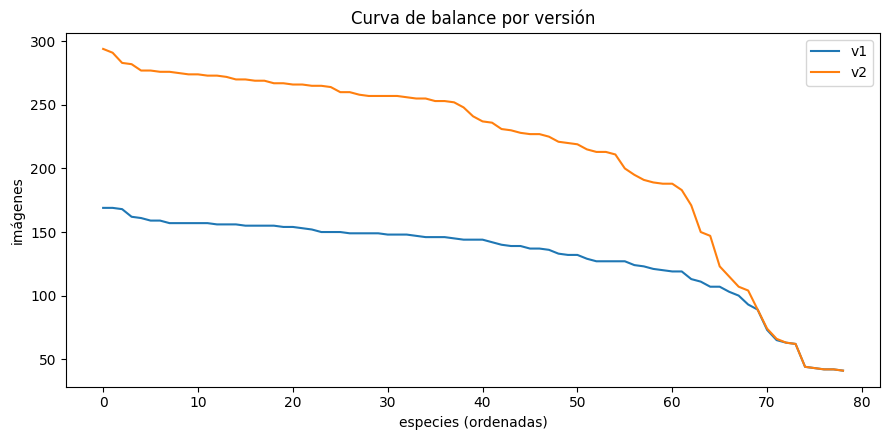

In [19]:
balance = pd.DataFrame({
    nombre: pd.Series({e: sum(len(sp[s]) for s in SPLITS)
                       for e, sp in m["reparto"].items()})
    for nombre, m in manifiestos.items()}).fillna(0).astype(int)

print(balance.agg(["min", "median", "max", "sum"]).to_string())
print("\ndesbalance (max/min):")
for nombre in balance:
    vivas = balance[nombre][balance[nombre] > 0]
    print(f"  {nombre}: {vivas.max() / vivas.min():.1f}x")

fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre in balance:
    ax.plot(sorted(balance[nombre][balance[nombre] > 0], reverse=True), label=nombre)
ax.set(xlabel="especies (ordenadas)", ylabel="imágenes", title="Curva de balance por versión")
ax.legend()
fig.tight_layout()
plt.show()

## 5 · Especies con menos imágenes

In [20]:
balance.assign(minimo=balance.min(axis=1)).nsmallest(12, "minimo").drop(columns="minimo")

,v1,v2
taygetis_sylvia,41,41
autochton_itylus,42,42
cissia_confusa,42,42
pseudodebis_puritana,43,43
pyrgus_adepta,44,44
pteronymia_latilla,62,62
euselasia_mys,63,63
pteronymia_aletta,65,66
magneuptychia_alcinoe,73,74
hypoleria_ocalea,89,89


## 6 · Qué cambió entre versiones

Cuántas imágenes entran, cuántas salen y cuántas se mueven de split. Lo último
importa: si una imagen pasa de train a test, las métricas entre versiones dejan
de ser comparables imagen a imagen.

In [21]:
nombres = list(manifiestos)
for anterior, siguiente in zip(nombres, nombres[1:]):
    a, b = manifiestos[anterior], manifiestos[siguiente]
    fa, fb = archivosDe(a), archivosDe(b)
    ubicacion = lambda m: {x: s for sp in m["reparto"].values() for s, arch in sp.items() for x in arch}
    ua, ub = ubicacion(a), ubicacion(b)
    movidas = [x for x in fa & fb if ua[x] != ub[x]]
    print(f"{anterior} -> {siguiente}")
    print(f"  entran {len(fb - fa):,} · salen {len(fa - fb):,} · comparten {len(fa & fb):,}")
    print(f"  cambian de split: {len(movidas):,} ({len(movidas) / max(len(fa & fb), 1):.1%} de las compartidas)")

v1 -> v2
  entran 6,526 · salen 15 · comparten 10,298
  cambian de split: 4,292 (41.7% de las compartidas)


## 7 · Fuga entre splits

Imágenes de test cuya observación también aparece en train: son fotos del mismo
individuo, así que inflan la métrica.

In [22]:
observacionDe = {m["archivo"]: m["observation_id"] for m in leerCsv(METADATA)}

for nombre, m in manifiestos.items():
    enTrain = {observacionDe[a] for a in archivosDe(m, "train") if a in observacionDe}
    test = [a for a in archivosDe(m, "test") if a in observacionDe]
    fugadas = sum(1 for a in test if observacionDe[a] in enTrain)
    print(f"{nombre}: {fugadas:,}/{len(test):,} ({fugadas / len(test):.1%})")

v1: 645/2,061 (31.3%)
v2: 1,069/3,364 (31.8%)


## 8 · Procedencia

In [23]:
meta = pd.DataFrame(leerCsv(METADATA)).drop_duplicates("photo_id")
for nombre, m in manifiestos.items():
    usadas = meta[meta.archivo.isin(archivosDe(m))]
    print(f"{nombre}: {len(usadas):,} fotos · "
          f"{usadas.observation_id.nunique():,} observaciones "
          f"({len(usadas) / usadas.observation_id.nunique():.2f} fotos/obs)")
    print(f"   licencias: {dict(usadas.licencia.value_counts())}")
    if "quality_grade" in usadas and usadas.quality_grade.any():
        print(f"   quality_grade: {dict(usadas.quality_grade.value_counts())}")

v1: 10,313 fotos · 7,926 observaciones (1.30 fotos/obs)
   licencias: {'cc-by-nc': np.int64(7169), 'cc-by': np.int64(1660), 'cc-by-sa': np.int64(757), 'cc-by-nc-sa': np.int64(525), 'cc0': np.int64(202)}
v2: 16,824 fotos · 12,808 observaciones (1.31 fotos/obs)
   licencias: {'cc-by-nc': np.int64(12161), 'cc-by': np.int64(2555), 'cc-by-sa': np.int64(1008), 'cc-by-nc-sa': np.int64(778), 'cc0': np.int64(322)}
   quality_grade: {'': np.int64(10298), 'research': np.int64(6526)}


## 9 · Muestra de imágenes

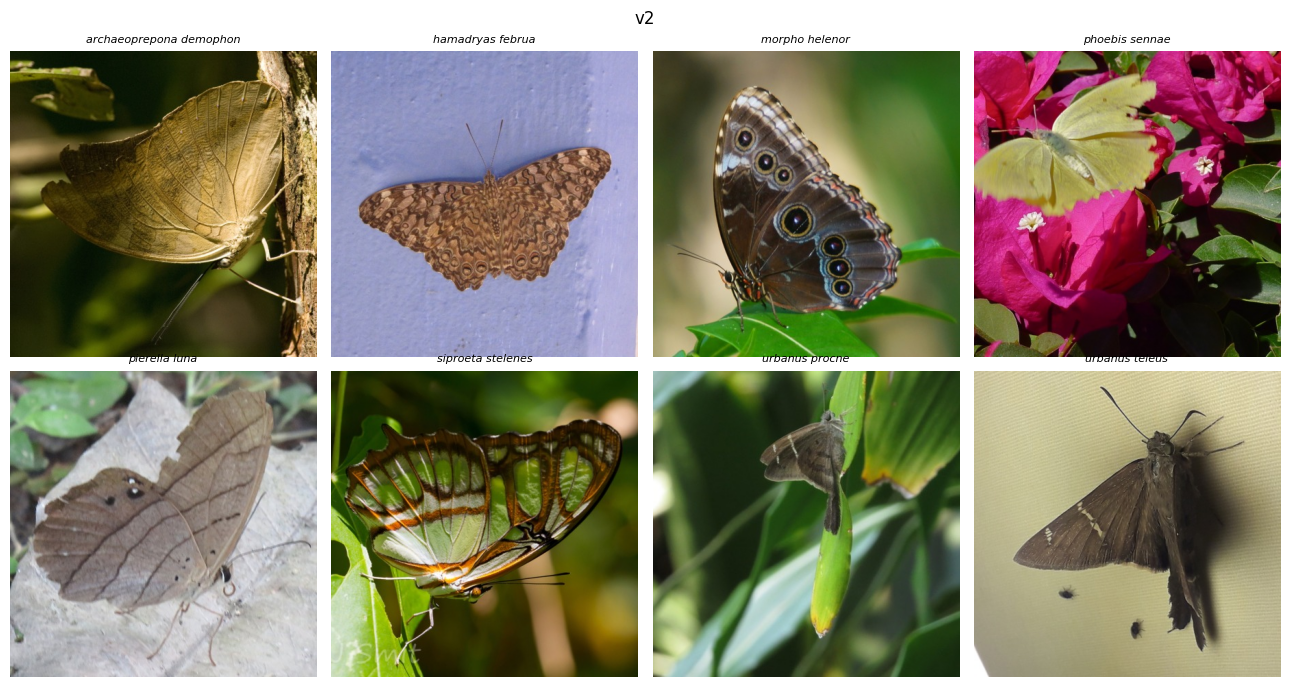

In [24]:
VERSION_MUESTRA = list(manifiestos)[-1]
rng = np.random.default_rng(42)
m = manifiestos[VERSION_MUESTRA]
especies = sorted(rng.choice(sorted(m["reparto"]), 8, replace=False))

fig, ejes = plt.subplots(2, 4, figsize=(13, 7))
for ax, especie in zip(ejes.ravel(), especies):
    archivo = m["reparto"][especie]["train"][0]
    ax.imshow(plt.imread(PROCESADO_DIR / VERSION_MUESTRA / especie / archivo))
    ax.set_title(especie.replace("_", " "), fontsize=8, style="italic")
    ax.axis("off")
fig.suptitle(VERSION_MUESTRA)
fig.tight_layout()
plt.show()